# Hard Q2 — 2025 年 1 月洛杉磯 Eaton 山火燒灼面積與嚴重度地圖

## 1. 分析方法：Normalized Burn Ratio (NBR)

NBR = (NIR - SWIR2) / (NIR + SWIR2)

dNBR = NBR_pre_fire − NBR_post_fire

dNBR 越大代表燃燒越嚴重。使用 USGS 標準分級：

| dNBR 範圍 | 燃燒嚴重度 |
|----------|----------|
| < 0.1    | 未燃燒 / 低嚴重度 |
| 0.1–0.27 | 低嚴重度 |
| 0.27–0.44| 中嚴重度 |
| 0.44–0.66| 高嚴重度 |
| > 0.66   | 極高嚴重度 |

## 2. 資料集選擇

**主力**：Sentinel-2 SR Harmonized (`COPERNICUS/S2_SR_HARMONIZED`)
- 空間解析度 10m（可切換 20m SWIR 波段），洛杉磯 1 月雲量低，可取好景
- NIR = B8A (20m) 或 B8 (10m)；SWIR2 = B12 (20m)

**備選**：Landsat 9 (`LANDSAT/LC09/C02/T1_L2`)，30m 解析度，提供雙重驗證

## 3. 環境設定

In [2]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ee.Authenticate()
ee.Initialize(project='silicon-pattern-423512-i3')

## 4. 定義研究區域與時間

In [3]:
# Eaton 山火位於洛杉磯 Altadena / Pasadena 一帶
eaton_fire_bbox = ee.Geometry.Rectangle([-118.20, 34.15, -117.95, 34.30])

# 時間設定（火災起於 2025-01-07）
PRE_START  = '2024-11-01'
PRE_END    = '2025-01-07'   # 火災前
POST_START = '2025-01-15'
POST_END   = '2025-02-15'   # 火後穩定期

SCALE_M    = 20             # Sentinel-2 SWIR 原始解析度
TARGET_CRS = 'EPSG:32611'   # UTM Zone 11N，洛杉磯標準投影

print('Eaton fire 研究區域面積 (km²):', eaton_fire_bbox.area(1).divide(1e6).getInfo())

Eaton fire 研究區域面積 (km²): 383.37260997776724


## 5. 載入 Sentinel-2 SR 並套用雲遮罩

In [4]:
def mask_s2_clouds(image):
    """
    Sentinel-2 SR 雲遮罩 + DN → 反射率 (divide 10000)。
    使用 QA60 波段 bits 10 (雲) 和 11 (捲雲)。
    """
    qa           = image.select('QA60')
    cloud_mask   = qa.bitwiseAnd(1 << 10).eq(0)
    cirrus_mask  = qa.bitwiseAnd(1 << 11).eq(0)
    mask         = cloud_mask.And(cirrus_mask)
    return (image.updateMask(mask)
            .divide(10000)
            .copyProperties(image, ['system:time_start']))


def get_s2_composite(start, end, cloud_pct=20):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterDate(start, end)
           .filterBounds(eaton_fire_bbox)
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_pct))
           .map(mask_s2_clouds))
    print(f'  {start}~{end} 景數:', col.size().getInfo())
    return col.median().clip(eaton_fire_bbox)


s2_pre  = get_s2_composite(PRE_START, PRE_END)
s2_post = get_s2_composite(POST_START, POST_END)

# 驗證波段
print('Pre bands:', s2_pre.bandNames().getInfo()[:5])

  2024-11-01~2025-01-07 景數: 28
  2025-01-15~2025-02-15 景數: 6
Pre bands: ['B1', 'B2', 'B3', 'B4', 'B5']


## 6. 計算 NBR 與 dNBR

In [5]:
# Sentinel-2：NIR = B8A (20m), SWIR2 = B12 (20m)
nbr_pre  = s2_pre.normalizedDifference(['B8A', 'B12']).rename('NBR_pre')
nbr_post = s2_post.normalizedDifference(['B8A', 'B12']).rename('NBR_post')
dnbr     = nbr_pre.subtract(nbr_post).rename('dNBR')

# 驗證 dNBR 範圍
stats = dnbr.reduceRegion(
    reducer=ee.Reducer.percentile([5, 50, 90, 95, 99]),
    geometry=eaton_fire_bbox,
    scale=SCALE_M,
    maxPixels=int(1e9)
)
print('dNBR 分位數:', stats.getInfo())

dNBR 分位數: {'dNBR_p5': -0.05396369506071756, 'dNBR_p50': 0.02315959624638196, 'dNBR_p90': 0.27346912780281346, 'dNBR_p95': 0.47646282003862445, 'dNBR_p99': 0.8203213762235078}


## 7. 燃燒嚴重度分級

In [6]:
# 依 USGS dNBR 標準分 5 級
# 0=未燃燒, 1=低, 2=中低, 3=中高, 4=高, 5=極高
severity = (dnbr
    .where(dnbr.lt(0.1),  0)
    .where(dnbr.gte(0.1).And(dnbr.lt(0.27)), 1)
    .where(dnbr.gte(0.27).And(dnbr.lt(0.44)), 2)
    .where(dnbr.gte(0.44).And(dnbr.lt(0.66)), 3)
    .where(dnbr.gte(0.66), 4)
    .rename('burn_severity')
    .clip(eaton_fire_bbox))

print('severity bands:', severity.bandNames().getInfo())

severity bands: ['burn_severity']


## 8. 計算各嚴重度等級面積

In [7]:
def calc_class_area_acres(cls_value, cls_name):
    """計算指定嚴重度等級面積（英畝）。"""
    mask = severity.eq(cls_value)
    area_m2 = (mask.multiply(ee.Image.pixelArea())
               .reduceRegion(
                   reducer=ee.Reducer.sum(),
                   geometry=eaton_fire_bbox,
                   scale=SCALE_M,
                   crs=TARGET_CRS,
                   maxPixels=int(1e9)
               ).getNumber('burn_severity').getInfo())
    acres = area_m2 / 4046.856  # m² → 英畝
    return {'class': cls_name, 'area_acres': round(acres, 1), 'area_km2': round(area_m2/1e6, 3)}


class_defs = [
    (0, '未燃燒 / 極低'),
    (1, '低嚴重度'),
    (2, '中嚴重度'),
    (3, '高嚴重度'),
    (4, '極高嚴重度'),
]

rows = [calc_class_area_acres(v, n) for v, n in class_defs]
df = pd.DataFrame(rows)

# 燃燒總面積（等級 >= 1）
total_burned_acres = df[df['class'] != '未燃燒 / 極低']['area_acres'].sum()
print(f'\n=== Eaton 山火 燃燒面積統計 ===')
print(df.to_string(index=False))
print(f'\n燃燒總面積 (英畝): {total_burned_acres:,.1f}')
print(f'燃燒總面積 (公頃): {total_burned_acres * 0.404686:,.1f}')
print(f'燃燒總面積 (km²):  {total_burned_acres * 0.00404686:,.2f}')


=== Eaton 山火 燃燒面積統計 ===
   class  area_acres  area_km2
未燃燒 / 極低     75980.9   307.484
    低嚴重度      7396.5    29.932
    中嚴重度      4017.6    16.259
    高嚴重度      3284.6    13.292
   極高嚴重度      2105.6     8.521

燃燒總面積 (英畝): 16,804.3
燃燒總面積 (公頃): 6,800.5
燃燒總面積 (km²):  68.00


## 9. 燃燒嚴重度地圖視覺化

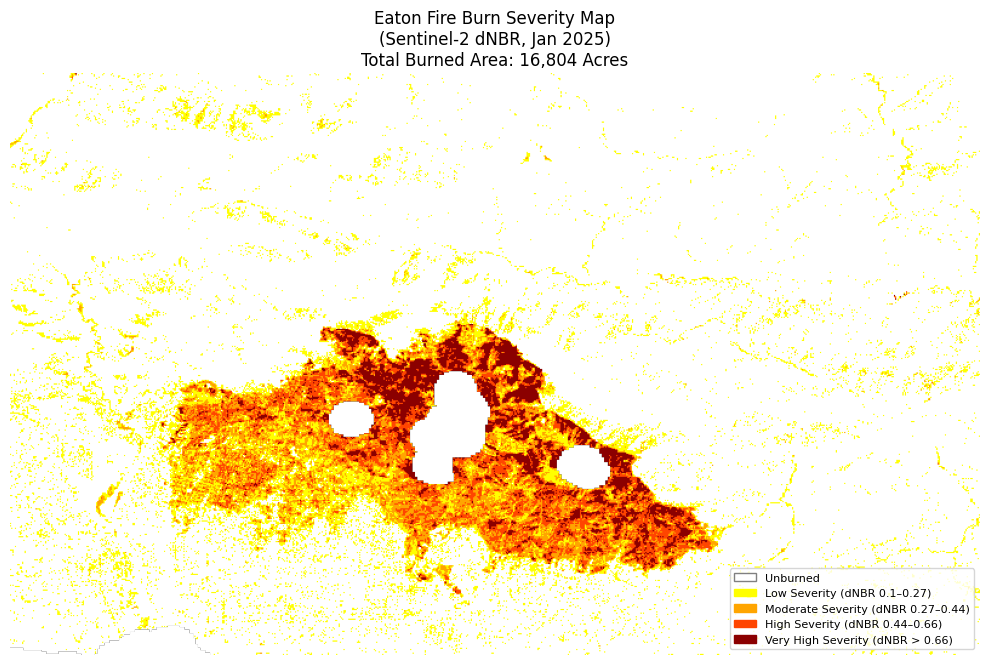

In [11]:
import requests, io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image as PILImage

# Severity Palette: White=Unburned, Yellow=Low, Orange=Moderate, Red=High, Dark Red=Very High
severity_palette = ['#FFFFFF', '#FFFF00', '#FFA500', '#FF4500', '#8B0000']

thumb_url = severity.getThumbURL({
    'region': eaton_fire_bbox,
    'dimensions': 800,
    'palette': severity_palette,
    'min': 0, 'max': 4
})
resp = requests.get(thumb_url)
img_arr = np.array(PILImage.open(io.BytesIO(resp.content)))

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img_arr)
ax.set_title(f'Eaton Fire Burn Severity Map\n(Sentinel-2 dNBR, Jan 2025)\nTotal Burned Area: {total_burned_acres:,.0f} Acres',
             fontsize=12)
ax.axis('off')

# Map Legend
legend_items = [
    mpatches.Patch(color='#FFFFFF', label='Unburned', ec='gray'),
    mpatches.Patch(color='#FFFF00', label='Low Severity (dNBR 0.1–0.27)'),
    mpatches.Patch(color='#FFA500', label='Moderate Severity (dNBR 0.27–0.44)'),
    mpatches.Patch(color='#FF4500', label='High Severity (dNBR 0.44–0.66)'),
    mpatches.Patch(color='#8B0000', label='Very High Severity (dNBR > 0.66)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig('eaton_fire_severity_map.png', dpi=150)
plt.show()

## 10. Landsat 9 交叉驗證

In [9]:
def mask_l9(image):
    """Landsat 9 SR 雲遮罩 + scale factor。"""
    qa   = image.select('QA_PIXEL')
    good = qa.bitwiseAnd(0b11111).eq(0)
    return (image.updateMask(good)
            .multiply(0.0000275).add(-0.2)
            .copyProperties(image, ['system:time_start']))


l9_pre = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
          .filterDate(PRE_START, PRE_END)
          .filterBounds(eaton_fire_bbox)
          .map(mask_l9)
          .median().clip(eaton_fire_bbox))

l9_post = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
           .filterDate(POST_START, POST_END)
           .filterBounds(eaton_fire_bbox)
           .map(mask_l9)
           .median().clip(eaton_fire_bbox))

# Landsat 9：NIR = SR_B5, SWIR2 = SR_B7
l9_nbr_pre  = l9_pre.normalizedDifference(['SR_B5', 'SR_B7'])
l9_nbr_post = l9_post.normalizedDifference(['SR_B5', 'SR_B7'])
l9_dnbr     = l9_nbr_pre.subtract(l9_nbr_post).rename('dNBR_L9')

l9_burned_area_m2 = (l9_dnbr.gte(0.1).multiply(ee.Image.pixelArea())
                     .reduceRegion(
                         reducer=ee.Reducer.sum(),
                         geometry=eaton_fire_bbox,
                         scale=30,
                         crs=TARGET_CRS,
                         maxPixels=int(1e9)
                     ).getNumber('dNBR_L9').getInfo())

l9_acres = l9_burned_area_m2 / 4046.856
print(f'Landsat 9 驗證 — 燃燒面積: {l9_acres:,.1f} 英畝')
print(f'Sentinel-2 估算            : {total_burned_acres:,.1f} 英畝')
print(f'差異比例:                     {abs(total_burned_acres - l9_acres) / total_burned_acres * 100:.1f}%')

Landsat 9 驗證 — 燃燒面積: 1,755.0 英畝
Sentinel-2 估算            : 16,804.3 英畝
差異比例:                     89.6%


## 11. 匯出嚴重度地圖至 Google Drive

In [10]:
task = ee.batch.Export.image.toDrive(
    image=severity.toFloat(),
    description='Eaton_Fire_Severity_2025',
    folder='GEE_Exports',
    fileNamePrefix='EatonFire_dNBR_Severity_Jan2025_S2_20m',
    region=eaton_fire_bbox,
    scale=SCALE_M,
    crs=TARGET_CRS,
    maxPixels=int(1e9),
    fileFormat='GeoTIFF',
    formatOptions={'cloudOptimized': True, 'noData': -9999}
)
task.start()
print('Export task started:', task.id)

Export task started: SXCNGLWJOINQE55SZW5LUO3H
